## Feature Engineering and Encoding

### 1. Import Python Libraries and set properties for the notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import duckdb
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import gc
import category_encoders as ce

In [2]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### 2. Import data from the raw file

In [3]:
train_filepath = '../data/processed/neiss_clean_train.parquet'
eval_filepath = '../data/processed/neiss_clean_eval.parquet'
holdout_filepath =  '../data/processed/neiss_clean_holdout.parquet'

In [4]:
train_data= pd.read_parquet(train_filepath)
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

### 3. Feature Engineering 

#### 3.1 Imputation for missing Age

There are 357 rows with zero age. We can fill in the median age for records missing an age.

Applying the age imputation for train data set

In [5]:
zero_age_count = train_data[train_data[['Age']].Age == 0].shape
print(f'Count of records with zero age in train data before change:{zero_age_count[0]}')

median_train_age = train_data.Age.median()
print(f'Median age - train dataset:{median_train_age}')
train_data['Age'] = train_data['Age'].replace(0, median_train_age)

zero_age_count = train_data[train_data[['Age']].Age == 0].shape
print(f'Count of records with zero age in train data after change:{zero_age_count[0]}')

train_data.Age.describe()

Count of records with zero age in train data before change:357
Median age - train dataset:22.0
Count of records with zero age in train data after change:0


count   5120468.00
mean         30.95
std          26.16
min           0.08
25%           9.00
50%          22.00
75%          50.00
max         113.00
Name: Age, dtype: float64

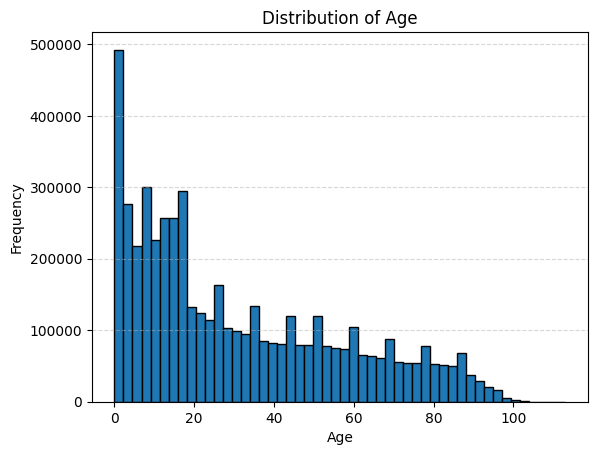

In [6]:
train_data[['Age']].Age.plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Applying the age imputation for evalaution data set

In [7]:
zero_age_count = eval_data[eval_data[['Age']].Age == 0].shape
print(f'Count of records with zero age in evaluation data before change:{zero_age_count[0]}')

median_eval_age = eval_data.Age.median()
print(f'Median age - evaluation dataset:{median_train_age}')
eval_data['Age'] = eval_data['Age'].replace(0, median_eval_age)

zero_age_count = eval_data[eval_data[['Age']].Age == 0].shape
print(f'Count of records with zero age in train data after change:{zero_age_count[0]}')

eval_data.Age.describe()

Count of records with zero age in evaluation data before change:70
Median age - evaluation dataset:22.0
Count of records with zero age in train data after change:0


count   1097244.00
mean         30.97
std          26.16
min           0.08
25%           9.00
50%          22.00
75%          50.00
max         113.00
Name: Age, dtype: float64

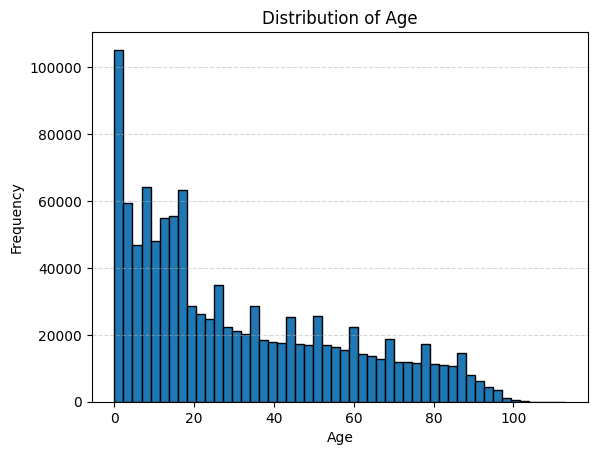

In [8]:
eval_data[['Age']].Age.plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Applying the age imputation for holdout data set

In [9]:
zero_age_count = holdout_data[holdout_data[['Age']].Age == 0].shape
print(f'Count of records with zero age in evaluation data before change:{zero_age_count[0]}')

median_holdout_age = holdout_data.Age.median()
print(f'Median age - evaluation dataset:{median_holdout_age}')
holdout_data['Age'] = holdout_data['Age'].replace(0, median_holdout_age)

zero_age_count = holdout_data[holdout_data[['Age']].Age == 0].shape
print(f'Count of records with zero age in train data after change:{zero_age_count[0]}')

holdout_data.Age.describe()

Count of records with zero age in evaluation data before change:77
Median age - evaluation dataset:22.0
Count of records with zero age in train data after change:0


count   1097244.00
mean         30.95
std          26.15
min           0.08
25%           9.00
50%          22.00
75%          50.00
max         112.00
Name: Age, dtype: float64

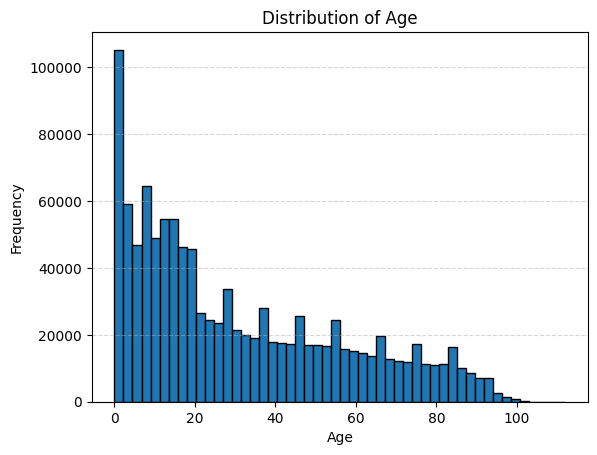

In [10]:
holdout_data[['Age']].Age.plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### 3.2 Add True Alcohol Flag

Create a True Alcohol feature based on the Narrative

In [11]:
train_data.Alcohol.value_counts()

Alcohol
3.00    3698329
0.00    1395125
1.00      27014
Name: count, dtype: int64

In [12]:
# Create a list of keywords (standard NEISS abbreviations)
alcohol_keywords = [
    # Medical & Formal
    'ALCOHOL', 'ETOH', 'INTOXICATED', 'INEBRIATED', 'DRUNK', 
    'SOBER', # Often appears as "Not Sober" or "Sobering up"
    'BAC ',  # Blood Alcohol Content (Need the space to avoid 'BACK')
    
    # Beverages
    'BEER', 'WINE', 'LIQUOR', 'VODKA', 'WHISKEY', 'WHISKY', 
    'TEQUILA', 'RUM', 'GIN', 'BRANDY', 'CHAMPAGNE', 'MOONSHINE',
    
    # Actions/Context
    'DRINKING', 'PARTY', 'BAR', 'PUB', 'CLUB', 'TAVERN',
    'HAPPY HOUR', 'KEG'
]

# Create a new column that searches the Narrative for these words
# Returns True if found, False if not
train_data['Alcohol_byNarrative'] = train_data['Narrative_1'].str.contains('|'.join(alcohol_keywords), case=False, na=False)
train_data['Alcohol_byNarrative'] = train_data['Alcohol_byNarrative'].astype(float)

eval_data['Alcohol_byNarrative'] = eval_data['Narrative_1'].str.contains('|'.join(alcohol_keywords), case=False, na=False)
eval_data['Alcohol_byNarrative'] = eval_data['Alcohol_byNarrative'].astype(float)

holdout_data['Alcohol_byNarrative'] = holdout_data['Narrative_1'].str.contains('|'.join(alcohol_keywords), case=False, na=False)
holdout_data['Alcohol_byNarrative'] = holdout_data['Alcohol_byNarrative'].astype(float)


# Check how many you found
#data['True_Alcohol_Flag'] = data['Alcohol_bool'] | data['Alcohol_Text_Flag']
print("Train Data Statistics")
print(train_data['Alcohol_byNarrative'].value_counts())

print("Evaluation Data Statistics")
print(eval_data['Alcohol_byNarrative'].value_counts())

print("Holdout Data Statistics")
print(holdout_data['Alcohol_byNarrative'].value_counts())


Train Data Statistics
Alcohol_byNarrative
0.00    4794544
1.00     325924
Name: count, dtype: int64
Evaluation Data Statistics
Alcohol_byNarrative
0.00    1027085
1.00      70159
Name: count, dtype: int64
Holdout Data Statistics
Alcohol_byNarrative
0.00    1027125
1.00      70119
Name: count, dtype: int64


Combine Alochol by narrative and alcohol = Yes to generate True Alcohol Flag for Train Dataset

In [13]:
target_cols = ['Alcohol', 'Alcohol_byNarrative']
train_data['True_Alcohol'] = 0
mask_3 = train_data[target_cols].eq(3.0).any(axis=1)
train_data.loc[mask_3, 'True_Alcohol'] = 2
mask_1 = train_data[target_cols].eq(1).any(axis=1)
train_data.loc[mask_1, 'True_Alcohol'] = 1
print(train_data['Alcohol_byNarrative'].value_counts())
print(train_data['Alcohol'].value_counts())
print(train_data['True_Alcohol'].value_counts())
train_data.drop(columns=['Alcohol_byNarrative'], inplace=True)

Alcohol_byNarrative
0.00    4794544
1.00     325924
Name: count, dtype: int64
Alcohol
3.00    3698329
0.00    1395125
1.00      27014
Name: count, dtype: int64
True_Alcohol
2    3472650
0    1321016
1     326802
Name: count, dtype: int64


Combine Alochol by narrative and alcohol = Yes to generate True Alcohol Flag for Evaluation Dataset

In [14]:
target_cols = ['Alcohol', 'Alcohol_byNarrative']
eval_data['True_Alcohol'] = 0
mask_3 = eval_data[target_cols].eq(3.0).any(axis=1)
eval_data.loc[mask_3, 'True_Alcohol'] = 2
mask_1 = eval_data[target_cols].eq(1).any(axis=1)
eval_data.loc[mask_1, 'True_Alcohol'] = 1
print(eval_data['Alcohol_byNarrative'].value_counts())
print(eval_data['Alcohol'].value_counts())
print(eval_data['True_Alcohol'].value_counts())
eval_data.drop(columns=['Alcohol_byNarrative'], inplace=True)

Alcohol_byNarrative
0.00    1027085
1.00      70159
Name: count, dtype: int64
Alcohol
3.00    792500
0.00    298936
1.00      5808
Name: count, dtype: int64
True_Alcohol
2    744046
0    282852
1     70346
Name: count, dtype: int64


Combine Alochol by narrative and alcohol = Yes to generate True Alcohol Flag for holdout Dataset

In [15]:
target_cols = ['Alcohol', 'Alcohol_byNarrative']
holdout_data['True_Alcohol'] = 0
mask_3 = holdout_data[target_cols].eq(3.0).any(axis=1)
holdout_data.loc[mask_3, 'True_Alcohol'] = 2
mask_1 = holdout_data[target_cols].eq(1).any(axis=1)
holdout_data.loc[mask_1, 'True_Alcohol'] = 1
print(holdout_data['Alcohol_byNarrative'].value_counts())
print(holdout_data['Alcohol'].value_counts())
print(holdout_data['True_Alcohol'].value_counts())
holdout_data.drop(columns=['Alcohol_byNarrative'], inplace=True)

Alcohol_byNarrative
0.00    1027125
1.00      70119
Name: count, dtype: int64
Alcohol
3.00    792501
0.00    298860
1.00      5883
Name: count, dtype: int64
True_Alcohol
2    743948
0    282964
1     70332
Name: count, dtype: int64


#### 3.3 Add True Drug Flag

In [16]:
# 1. Define keywords for common substances & slang
drug_keywords = [
    # General Terms
    'DRUG', 'OVERDOSE', 'MEDICATION', 'PILL', 'TABLET', 'CAPSULE', 
    'INGEST', 'SUBSTANCE', 'NARCOTIC', 'OPIOID', 'OPIGTE', # Common typo
    
    # Street / Illegal
    'COCAINE', 'HEROIN', 'METHAMPHETAMINE', 'MARIJUANA', 'CANNABIS', 
    'FENTANYL', 'ECSTASY', 'MDMA', ' LSD ', ' PCP ', 'HASHISH',
    
    # Prescription / OTC (Brand & Generic)
    'XANAX', 'VALIUM', 'PERCOCET', 'VICODIN', 'OXYCODONE', 'OXYCONTIN',
    'ADDERALL', 'RITALIN', 'TYLENOL', 'ASPIRIN', 'IBUPROFEN', 'ADVIL',
    'MOTRIN', 'BENADRYL', 'INSULIN', 'VITAMIN', 'MORPHINE', 'CODEINE'
]
# 2. Create the Search Pattern (joins them with OR logic: "DRUG|OVERDOSE|...")
pattern = '|'.join(drug_keywords)
# 3. Create a True/False column based on the text
train_data['Drug_byNarrative'] = train_data['Narrative_1'].str.contains(pattern, case=False, na=False)
train_data['Drug_byNarrative'] = train_data['Drug_byNarrative'].astype(float)

eval_data['Drug_byNarrative'] = eval_data['Narrative_1'].str.contains(pattern, case=False, na=False)
eval_data['Drug_byNarrative'] = eval_data['Drug_byNarrative'].astype(float)

holdout_data['Drug_byNarrative'] = holdout_data['Narrative_1'].str.contains(pattern, case=False, na=False)
holdout_data['Drug_byNarrative'] = holdout_data['Drug_byNarrative'].astype(float)


Combine Drug by narrative and Drug = Yes to generate True Drug Flag for train & eval and holdout Dataset

In [17]:
target_cols = ['Drug', 'Drug_byNarrative']
train_data['True_Drug'] = 0
mask_3 = train_data[target_cols].eq(3.0).any(axis=1)
train_data.loc[mask_3, 'True_Drug'] = 2
mask_1 = train_data[target_cols].eq(1).any(axis=1)
train_data.loc[mask_1, 'True_Drug'] = 1
print("Statistics for Train Data")
print(train_data['Drug_byNarrative'].value_counts())
print(train_data['Drug'].value_counts())
print(train_data['True_Drug'].value_counts())

print("Statistics for Evaluation Data")
target_cols = ['Drug', 'Drug_byNarrative']
eval_data['True_Drug'] = 0
mask_3 = eval_data[target_cols].eq(3.0).any(axis=1)
eval_data.loc[mask_3, 'True_Drug'] = 2
mask_1 = eval_data[target_cols].eq(1).any(axis=1)
eval_data.loc[mask_1, 'True_Drug'] = 1
print(eval_data['Drug_byNarrative'].value_counts())
print(eval_data['Drug'].value_counts())
print(eval_data['True_Drug'].value_counts())

print("Statistics for Holdout Data")
holdout_cols = ['Drug', 'Drug_byNarrative']
holdout_data['True_Drug'] = 0
mask_3 = holdout_data[holdout_cols].eq(3.0).any(axis=1)
holdout_data.loc[mask_3, 'True_Drug'] = 2
mask_1 = holdout_data[holdout_cols].eq(1).any(axis=1)
holdout_data.loc[mask_1, 'True_Drug'] = 1
print(holdout_data['Drug_byNarrative'].value_counts())
print(holdout_data['Drug'].value_counts())
print(holdout_data['True_Drug'].value_counts())

train_data.drop(columns=['Drug_byNarrative'], inplace=True)
eval_data.drop(columns=['Drug_byNarrative'], inplace=True)
holdout_data.drop(columns=['Drug_byNarrative'], inplace=True)



Statistics for Train Data
Drug_byNarrative
0.00    5015414
1.00     105054
Name: count, dtype: int64
Drug
3.00    3698329
0.00    1390487
1.00      31652
Name: count, dtype: int64
True_Drug
2    3632936
0    1366455
1     121077
Name: count, dtype: int64
Statistics for Evaluation Data
Drug_byNarrative
0.00    1075130
1.00      22114
Name: count, dtype: int64
Drug
3.00    792500
0.00    298141
1.00      6603
Name: count, dtype: int64
True_Drug
2    778614
0    293170
1     25460
Name: count, dtype: int64
Statistics for Holdout Data
Drug_byNarrative
0.00    1074595
1.00      22649
Name: count, dtype: int64
Drug
3.00    792501
0.00    298095
1.00      6648
Name: count, dtype: int64
True_Drug
2    778335
0    292925
1     25984
Name: count, dtype: int64


#### 3.4 Add Treatment Month 

Treatment month might help us understand when the hospitalization rate was higher

In [18]:
train_data['Treatment_Month'] = train_data['Treatment_Date'].dt.month.astype(int)
eval_data['Treatment_Month'] = eval_data['Treatment_Date'].dt.month.astype(int)
holdout_data['Treatment_Month'] = holdout_data['Treatment_Date'].dt.month.astype(int)

### 3.5 Extract Meaningful Information from the narrative flag

In [19]:
# Standradize the Narrative column to make everything uppercase and set the narrative to blanks if null.
narratives = train_data['Narrative_1'].fillna('').str.upper()
regex_patterns = {
        'EMS_Severity': r'\b(AMBULANCE|EMS|PARAMEDIC|UNCONSCIOUS|UNRESPONSIVE|CPR|HELICOPTER|FLIGHT|TRAUMA ALERT)\b',
        'Safety_Gear': r'\b(HELMET|PADS|GOGGLES|GLASSES|SEATBELT|HARNESS|GUARD|PROTECTIVE)\b',
        'Third_Party': r'\b(PUSHED|ASSAULT|FIGHT|BITE|BITTEN|HIT BY|THROWN|ANOTHER PERSON|ALTERCATION)\b',
        'Height_Risk': r'\b(ROOF|LADDER|SCAFFOLD|TREE|STAIRS|BALCONY|WINDOW)\b',
        'Water_Risk': r'\b(POOL|OCEAN|LAKE|BATHTUB|RIVER|HOT TUB|SWIMMING)\b'
    }
train_data['EMS_Severity_Flag'] = np.where(narratives.str.contains(regex_patterns['EMS_Severity'], regex=True), 1, 0)
train_data['Safety_Gear_Flag']  = np.where(narratives.str.contains(regex_patterns['Safety_Gear'], regex=True), 1, 0)
train_data['Third_Party_Flag']  = np.where(narratives.str.contains(regex_patterns['Third_Party'], regex=True), 1, 0)
train_data['Height_Risk_Flag']  = np.where(narratives.str.contains(regex_patterns['Height_Risk'], regex=True), 1, 0)
train_data['Water_Risk_Flag']   = np.where(narratives.str.contains(regex_patterns['Water_Risk'], regex=True), 1, 0)

print("\n--- Feature Extraction Summary (Positive Hits) ---")
print(f"EMS/Severity Involvements: {train_data['EMS_Severity_Flag'].sum():,}")
print(f"Safety Gear Mentions:      {train_data['Safety_Gear_Flag'].sum():,}")
print(f"Third-Party Altercations:  {train_data['Third_Party_Flag'].sum():,}")
print(f"Height-Related Incidents:  {train_data['Height_Risk_Flag'].sum():,}")
print(f"Water-Related Incidents:   {train_data['Water_Risk_Flag'].sum():,}")


# Create the features in the evaluation data

# Standradize the Narrative column to make everything uppercase and set the narrative to blanks if null.
narratives = eval_data['Narrative_1'].fillna('').str.upper()
eval_data['EMS_Severity_Flag'] = np.where(narratives.str.contains(regex_patterns['EMS_Severity'], regex=True), 1, 0)
eval_data['Safety_Gear_Flag']  = np.where(narratives.str.contains(regex_patterns['Safety_Gear'], regex=True), 1, 0)
eval_data['Third_Party_Flag']  = np.where(narratives.str.contains(regex_patterns['Third_Party'], regex=True), 1, 0)
eval_data['Height_Risk_Flag']  = np.where(narratives.str.contains(regex_patterns['Height_Risk'], regex=True), 1, 0)
eval_data['Water_Risk_Flag']   = np.where(narratives.str.contains(regex_patterns['Water_Risk'], regex=True), 1, 0)


# Create the features in the holdout data
# Standradize the Narrative column to make everything uppercase and set the narrative to blanks if null.
narratives = holdout_data['Narrative_1'].fillna('').str.upper()
holdout_data['EMS_Severity_Flag'] = np.where(narratives.str.contains(regex_patterns['EMS_Severity'], regex=True), 1, 0)
holdout_data['Safety_Gear_Flag']  = np.where(narratives.str.contains(regex_patterns['Safety_Gear'], regex=True), 1, 0)
holdout_data['Third_Party_Flag']  = np.where(narratives.str.contains(regex_patterns['Third_Party'], regex=True), 1, 0)
holdout_data['Height_Risk_Flag']  = np.where(narratives.str.contains(regex_patterns['Height_Risk'], regex=True), 1, 0)
holdout_data['Water_Risk_Flag']   = np.where(narratives.str.contains(regex_patterns['Water_Risk'], regex=True), 1, 0)



/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_54653/836218624.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  train_data['EMS_Severity_Flag'] = np.where(narratives.str.contains(regex_patterns['EMS_Severity'], regex=True), 1, 0)
/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_54653/836218624.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  train_data['Safety_Gear_Flag']  = np.where(narratives.str.contains(regex_patterns['Safety_Gear'], regex=True), 1, 0)
/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_54653/836218624.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  train_data['Third_Party_Flag']  = np.where(narratives.str.contains(regex_patterns['Third_Party'], regex=True), 1, 


--- Feature Extraction Summary (Positive Hits) ---
EMS/Severity Involvements: 51,656
Safety Gear Mentions:      61,797
Third-Party Altercations:  79,091
Height-Related Incidents:  321,757
Water-Related Incidents:   96,351


/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_54653/836218624.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eval_data['EMS_Severity_Flag'] = np.where(narratives.str.contains(regex_patterns['EMS_Severity'], regex=True), 1, 0)
/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_54653/836218624.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eval_data['Safety_Gear_Flag']  = np.where(narratives.str.contains(regex_patterns['Safety_Gear'], regex=True), 1, 0)
/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_54653/836218624.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eval_data['Third_Party_Flag']  = np.where(narratives.str.contains(regex_patterns['Third_Party'], regex=True), 1, 0)


#### 3.6 Add Injury Mechanism

In [20]:
# Standradize the Narrative column to make everything uppercase and set the narrative to blanks if null.
text_series = train_data['Narrative_1'].fillna('').str.upper()

# Define the patterns
patterns = {
        'Fall': r'\b(?:FELL|FALL|TRIPPED|SLIPPED|TUMBLED|JUMPED)\b',
        'Ingestion/Choking': r'\b(?:SWALLOWED|CHOKED|INGESTED|ATE|DRANK|COIN|BATTERY)\b',
        'Burn': r'\b(?:BURN|BURNED|SCALD|HOT|FIRE|FLAME|MELTED)\b',
        'Laceration/Cut': r'\b(?:CUT|LACERATION|SLICED|PIERCED|STABBED|GLASS)\b',
        'Struck By/Against': r'\b(?:STRUCK|HIT|SMASHED|CRUSHED|DROPPED ON|PINCHED)\b'
    }

# Create condiitonal masks/patterns
injury_conditions = [
        text_series.str.contains(patterns['Fall'], regex=True),
        text_series.str.contains(patterns['Ingestion/Choking'], regex=True),
        text_series.str.contains(patterns['Burn'], regex=True),
        text_series.str.contains(patterns['Laceration/Cut'], regex=True),
        text_series.str.contains(patterns['Struck By/Against'], regex=True)
    ]


injury_mechanism = [
        'Fall', 
        'Ingestion/Choking', 
        'Burn', 
        'Laceration/Cut', 
        'Struck By'
    ]

train_data['Injury_Mechanism'] = np.select(injury_conditions, injury_mechanism, default='Other/Unspecified')

print("Train Data Statistics after extraction")
print(train_data['Injury_Mechanism'].value_counts())

# Standradize the Narrative column to make everything uppercase and set the narrative to blanks if null.
text_series = eval_data['Narrative_1'].fillna('').str.upper()
# Create condiitonal masks/patterns
injury_conditions = [
        text_series.str.contains(patterns['Fall'], regex=True),
        text_series.str.contains(patterns['Ingestion/Choking'], regex=True),
        text_series.str.contains(patterns['Burn'], regex=True),
        text_series.str.contains(patterns['Laceration/Cut'], regex=True),
        text_series.str.contains(patterns['Struck By/Against'], regex=True)
    ]

eval_data['Injury_Mechanism'] = np.select(injury_conditions, injury_mechanism, default='Other/Unspecified')


print("Evaluation Data Statistics after extraction")
print(eval_data['Injury_Mechanism'].value_counts())

text_series = holdout_data['Narrative_1'].fillna('').str.upper()
# Create condiitonal masks/patterns
injury_conditions = [
        text_series.str.contains(patterns['Fall'], regex=True),
        text_series.str.contains(patterns['Ingestion/Choking'], regex=True),
        text_series.str.contains(patterns['Burn'], regex=True),
        text_series.str.contains(patterns['Laceration/Cut'], regex=True),
        text_series.str.contains(patterns['Struck By/Against'], regex=True)
    ]

holdout_data['Injury_Mechanism'] = np.select(injury_conditions, injury_mechanism, default='Other/Unspecified')


print("Holdout Data Statistics after extraction")
print(holdout_data['Injury_Mechanism'].value_counts())

Train Data Statistics after extraction
Injury_Mechanism
Fall                 2312971
Other/Unspecified    1827381
Laceration/Cut        426704
Struck By             398658
Burn                   86794
Ingestion/Choking      67960
Name: count, dtype: int64
Evaluation Data Statistics after extraction
Injury_Mechanism
Fall                 496223
Other/Unspecified    390592
Laceration/Cut        91733
Struck By             85783
Burn                  18324
Ingestion/Choking     14589
Name: count, dtype: int64
Holdout Data Statistics after extraction
Injury_Mechanism
Fall                 495406
Other/Unspecified    390735
Laceration/Cut        92271
Struck By             85713
Burn                  18527
Ingestion/Choking     14592
Name: count, dtype: int64


### 4. Understanding the relationship of the Target Variable with the Predictors - Use Training Data only

#### 4.1 Understand the relationship between Categorical Features and the Target Variable

In [21]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 36 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                float64       
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          str           
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       


In [22]:
cat_cols = train_data.select_dtypes(include=['object', 'category','str']).columns.tolist()
cat_cols 

['Other_Race',
 'Other_Diagnosis',
 'Other_Diagnosis_2',
 'Product_1',
 'Narrative_1',
 'Stratum',
 'Injury_Mechanism']

We dont need to include the above features in the predictor list as these are identifiers and do not provide any predictor signal and causes noise.

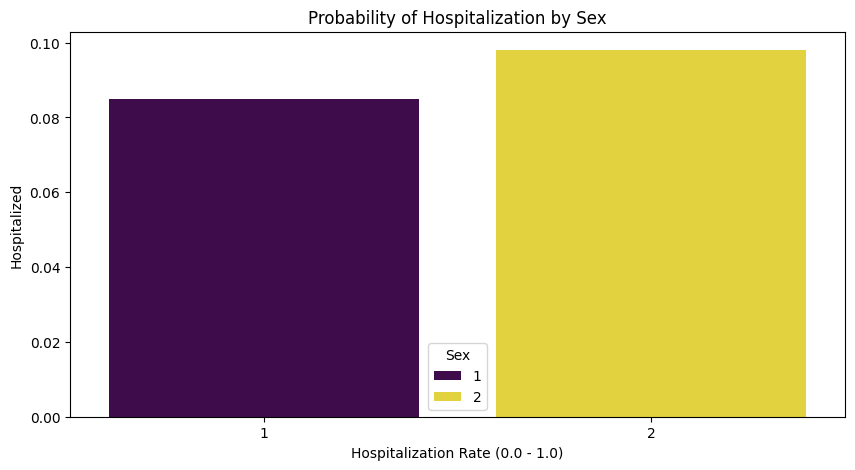

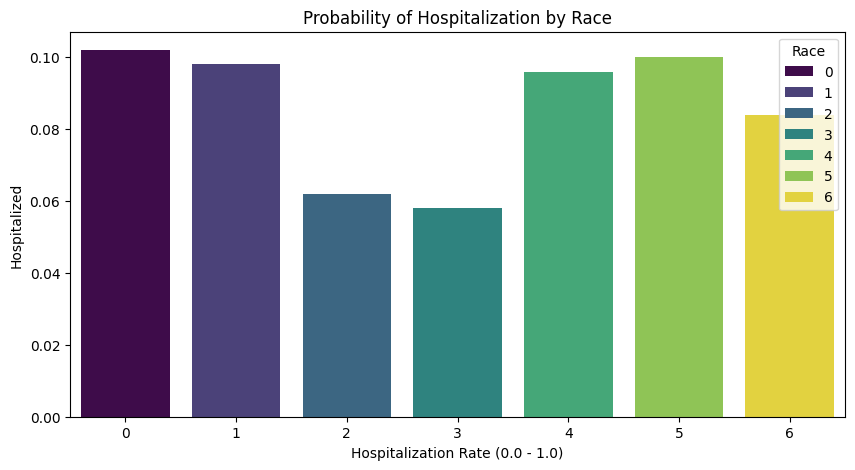

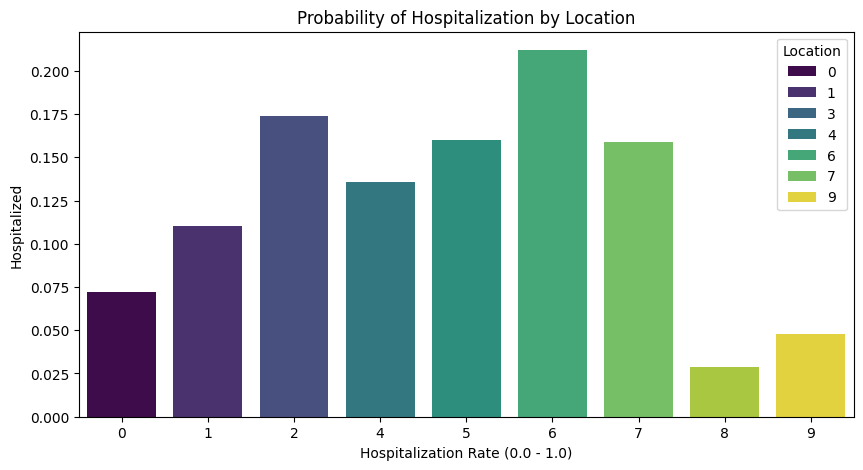

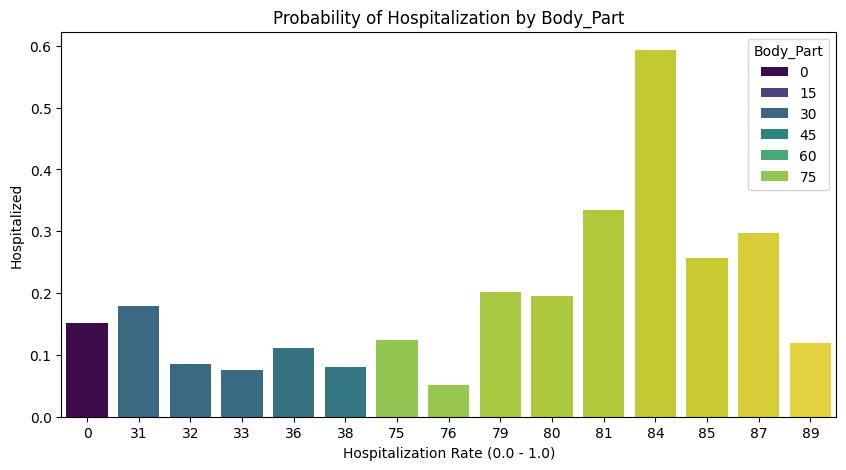

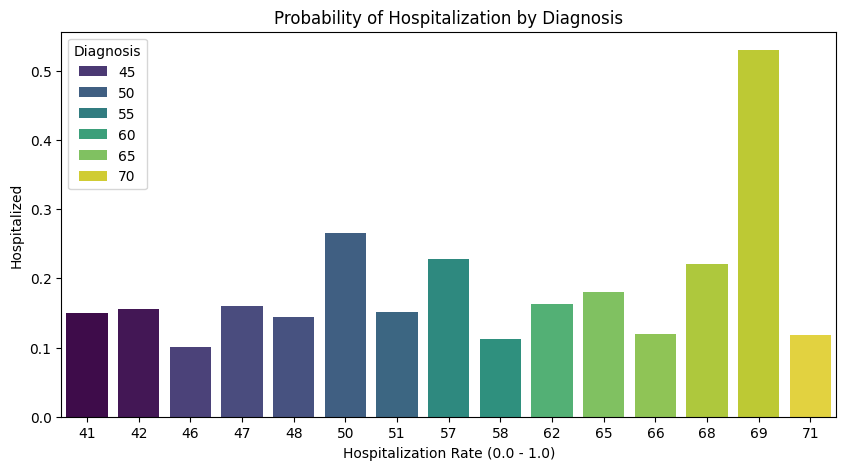

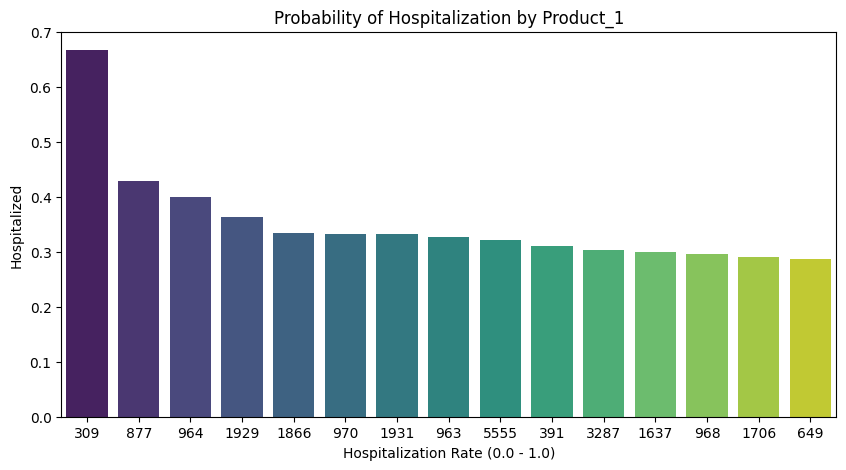

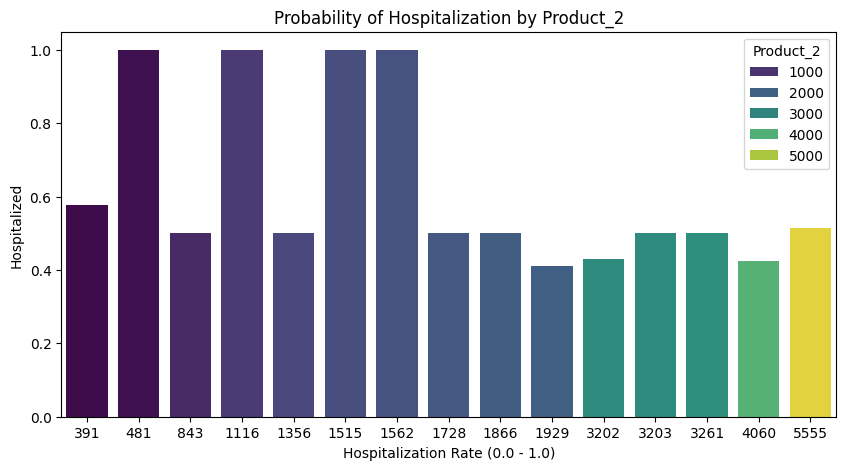

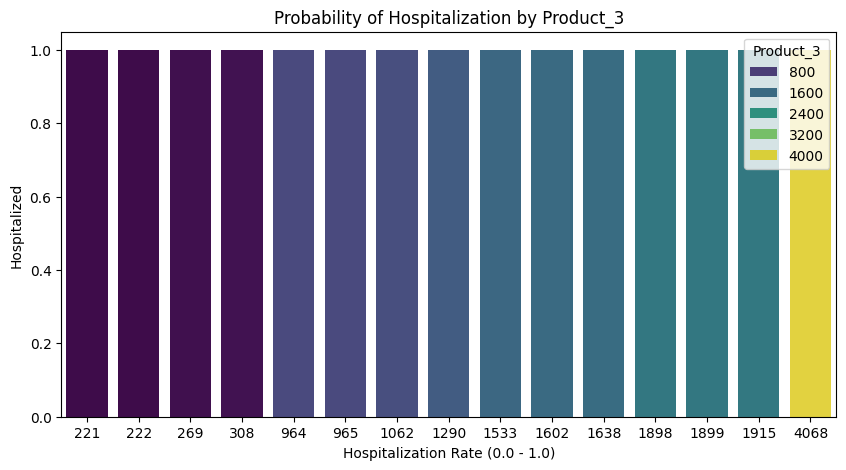

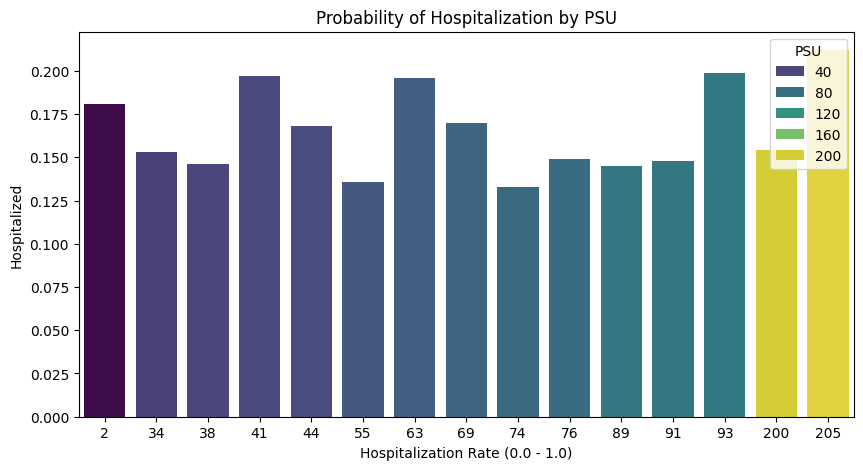

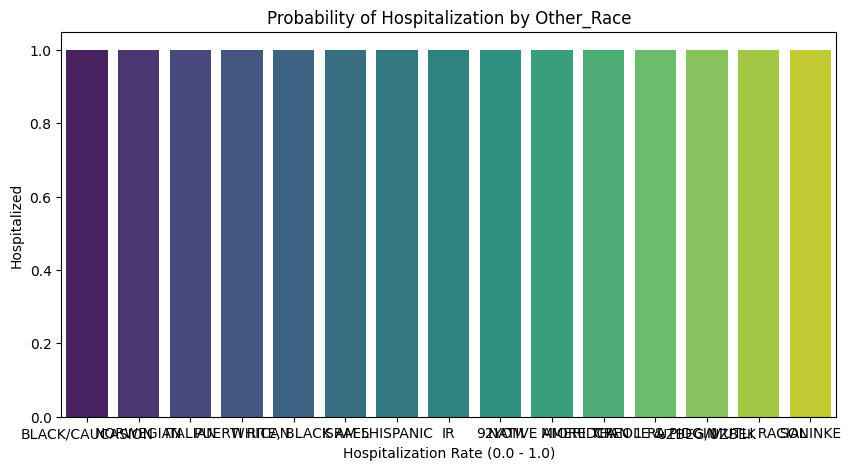

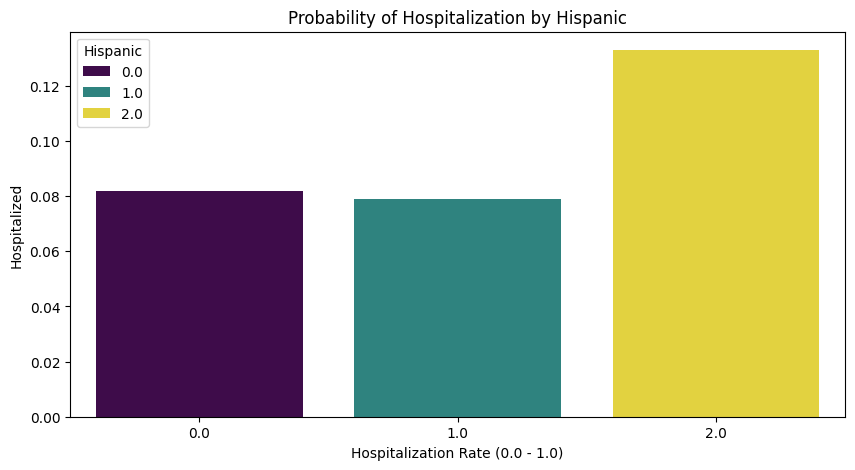

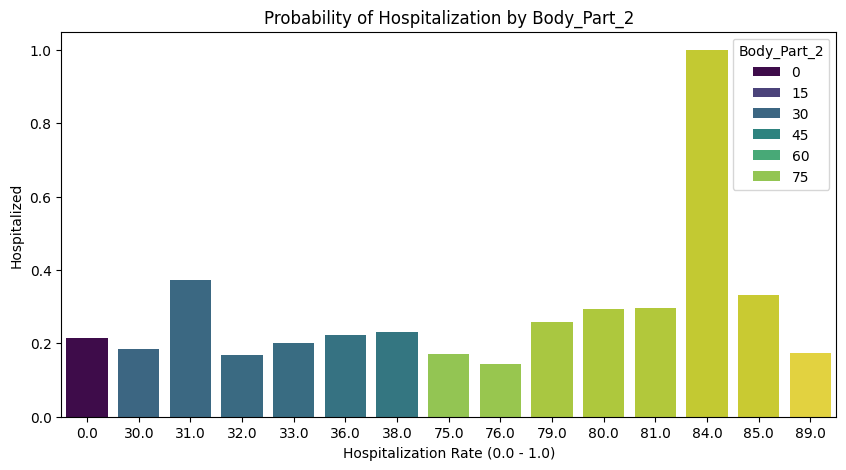

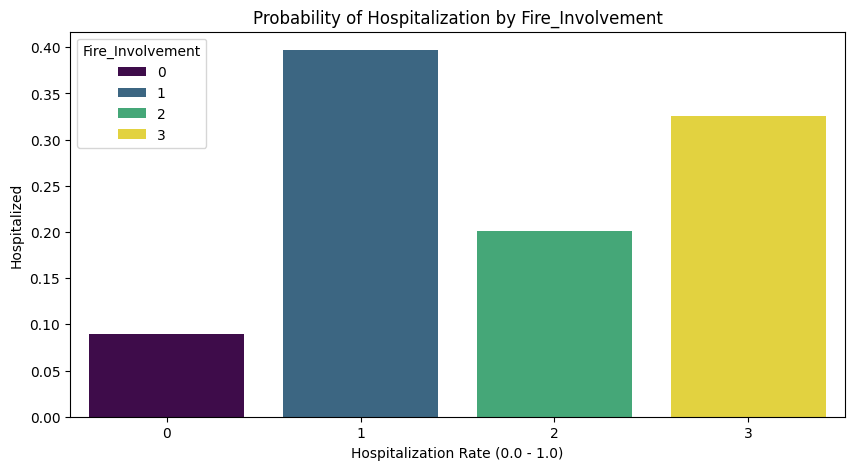

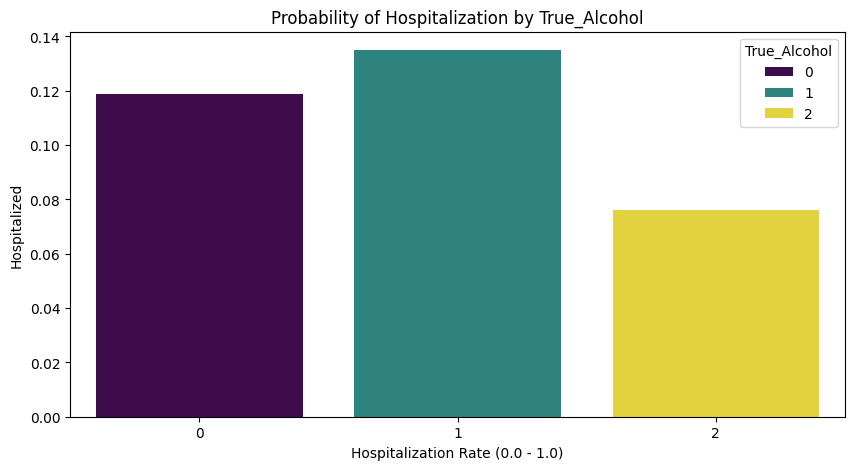

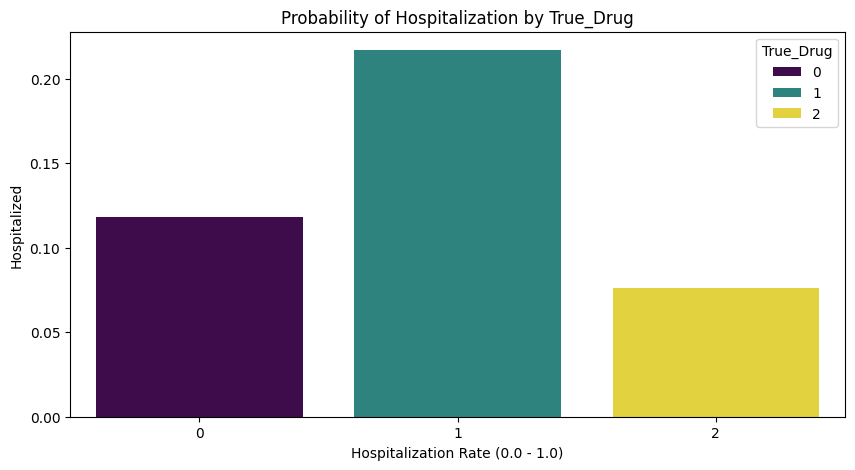

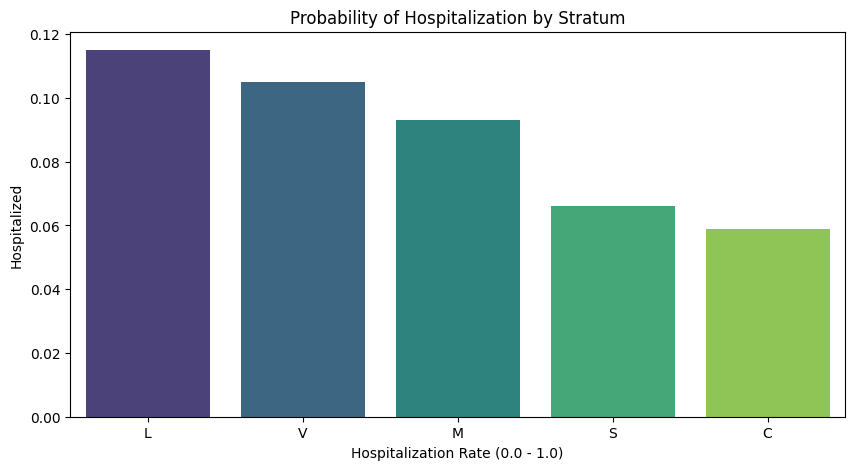

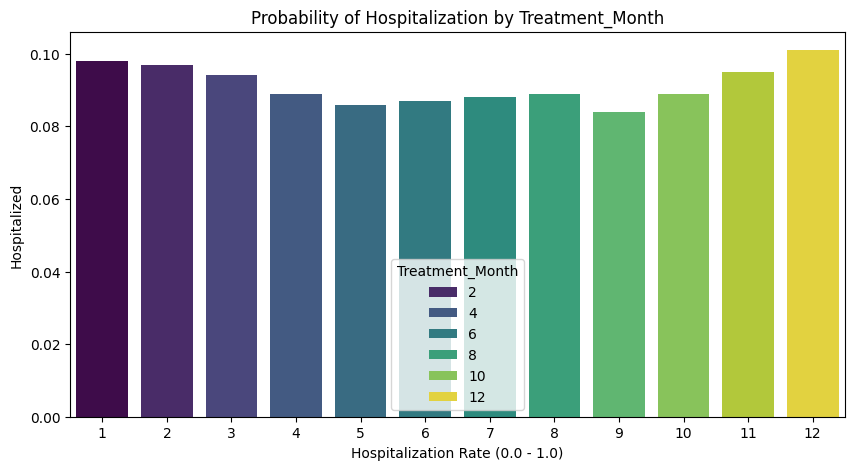

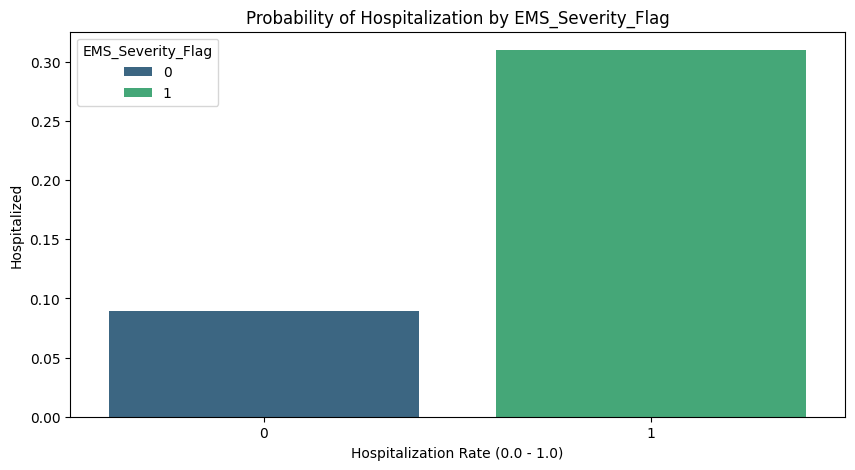

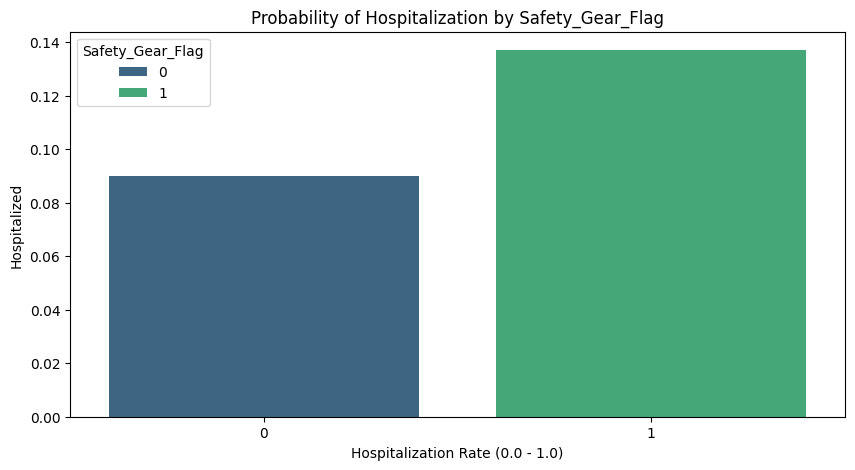

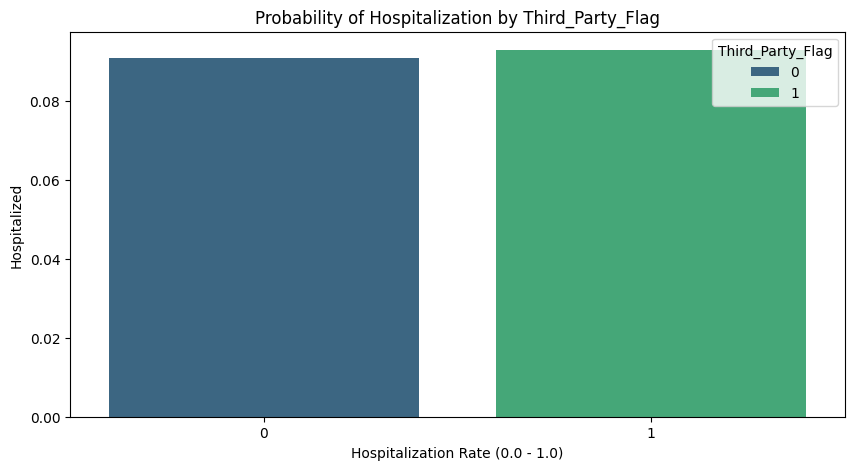

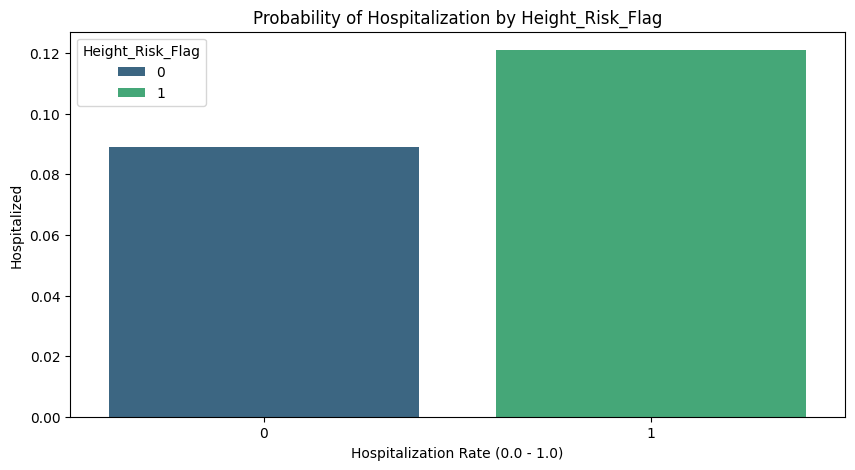

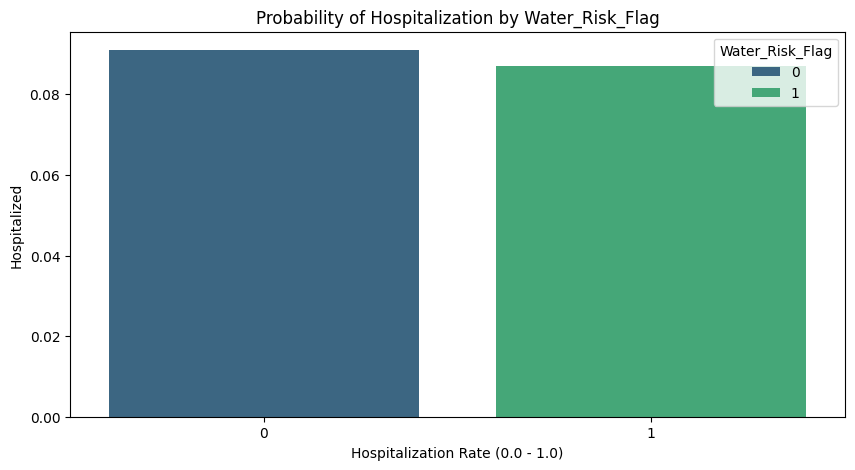

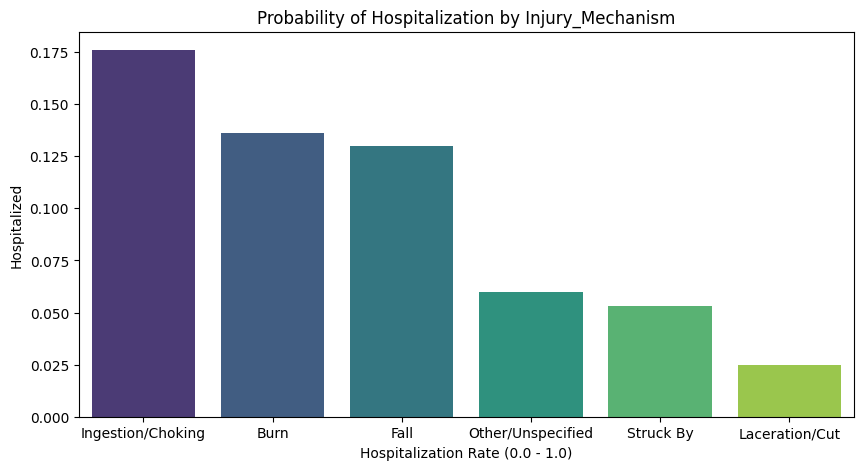

In [23]:
# Define all categorical variables to analyze
categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1','Product_2','Product_3','PSU','Other_Race','Hispanic','Body_Part_2','Fire_Involvement','True_Alcohol','True_Drug','Stratum','Treatment_Month','EMS_Severity_Flag','Safety_Gear_Flag','Third_Party_Flag','Height_Risk_Flag','Water_Risk_Flag','Injury_Mechanism']

# Loop through and plot the "Risk"
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Calculate the mean of 'Target_Hospitalized' (which equals the % hospitalized)
    risk_df = train_data.groupby(col)['Hospitalized'].mean().round(3).reset_index().sort_values('Hospitalized', ascending=False)
    
    # Plot top 15 categories for readability
    sns.barplot(y='Hospitalized', x=col, data=risk_df.head(15), dodge=False, palette='viridis',hue=col)
    
    plt.title(f'Probability of Hospitalization by {col}')
    ##plt.xticks(rotation=90)
    plt.xlabel('Hospitalization Rate (0.0 - 1.0)')
    plt.show()

### 4.2 Run Chi-Square/Cramers V test to understand which categorical variables are significant

In [24]:
categorical_cols

['Sex',
 'Race',
 'Location',
 'Body_Part',
 'Diagnosis',
 'Product_1',
 'Product_2',
 'Product_3',
 'PSU',
 'Other_Race',
 'Hispanic',
 'Body_Part_2',
 'Fire_Involvement',
 'True_Alcohol',
 'True_Drug',
 'Stratum',
 'Treatment_Month',
 'EMS_Severity_Flag',
 'Safety_Gear_Flag',
 'Third_Party_Flag',
 'Height_Risk_Flag',
 'Water_Risk_Flag',
 'Injury_Mechanism']

In [25]:
# Define categorical variables to analyze
#categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1','Other_Race','Hispanic','Fire_Involvement','True_Alcohol','True_Drug','Stratum','Treatment_Month']

# Loop through and plot the "Risk"
for col in categorical_cols:
    # Example: Check if Sex predicts Hospitalization
    contingency_table = pd.crosstab(train_data[col], train_data['Hospitalized'])
    #print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        print(f'{col} is a significant predictor.')
    else:
        print(f'{col} is likely noise.')

Sex is a significant predictor.
Race is a significant predictor.
Location is a significant predictor.
Body_Part is a significant predictor.
Diagnosis is a significant predictor.
Product_1 is a significant predictor.
Product_2 is a significant predictor.
Product_3 is a significant predictor.
PSU is a significant predictor.
Other_Race is a significant predictor.
Hispanic is a significant predictor.
Body_Part_2 is a significant predictor.
Fire_Involvement is a significant predictor.
True_Alcohol is a significant predictor.
True_Drug is a significant predictor.
Stratum is a significant predictor.
Treatment_Month is a significant predictor.
EMS_Severity_Flag is a significant predictor.
Safety_Gear_Flag is a significant predictor.
Third_Party_Flag is likely noise.
Height_Risk_Flag is a significant predictor.
Water_Risk_Flag is a significant predictor.
Injury_Mechanism is a significant predictor.


Per the chi-square test, all categorical variables a significant - this could be due to the volume of dataset - Large sample size effect. We need to further use the cramers V rule

In [26]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Your list of "Significant" variables
predictors = categorical_cols

# Calculate and Rank
results = []
for col in predictors:
    score = cramers_v(train_data[col], train_data['Hospitalized'])
    results.append({'Feature': col, 'Cramers_V Score': score})

# Show the leaderboard
rank_df = pd.DataFrame(results).sort_values(by='Cramers_V Score', ascending=False)
rank_df

,Feature,Cramers_V Score
4,Diagnosis,0.28
3,Body_Part,0.26
5,Product_1,0.23
8,PSU,0.15
22,Injury_Mechanism,0.14
2,Location,0.11
11,Body_Part_2,0.11
14,True_Drug,0.09
6,Product_2,0.08
17,EMS_Severity_Flag,0.08


#### Categorical Features that are significant

In [27]:
rank_df[rank_df['Cramers_V Score'] > 0.1]

,Feature,Cramers_V Score
4,Diagnosis,0.28
3,Body_Part,0.26
5,Product_1,0.23
8,PSU,0.15
22,Injury_Mechanism,0.14
2,Location,0.11
11,Body_Part_2,0.11


Store these variables in the predictor variable

In [28]:
predictors_cat = rank_df[rank_df['Cramers_V Score'] > 0.1].Feature.tolist()

We note that PSU has a high Cramers V score. But PSU represents the Primary Sampling unit (hospital id) and using that for ML could cause data leakage. We need to ignore this feature.

In [29]:
predictors_cat.pop(predictors_cat.index('PSU'))
predictors_cat

['Diagnosis',
 'Body_Part',
 'Product_1',
 'Injury_Mechanism',
 'Location',
 'Body_Part_2']

In [30]:
# # 1. Prepare the Data
# # Ensure categorical columns are numeric (codes)
# cols_to_plot = predictors_cat + ['Hospitalized'] 
# # 2. Calculate Correlation
# # method='spearman' is best for categorical codes
# corr_matrix = train_data[cols_to_plot].corr(method='spearman')

# # 3. Create the Plot
# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     corr_matrix, 
#     annot=True,     # Show the numbers
#     fmt=".2f",      # 2 decimal places
#     cmap='coolwarm',# Red = Positive, Blue = Negative
#     vmin=-1, vmax=1,# Lock scale between -1 and 1
#     linewidths=0.5  # Add white lines between squares
# )

# plt.title('Correlation Heatmap of NEISS Variables')
# plt.show()

#### 3.1 Understand the relationship between Numerical Features and the Target Variable

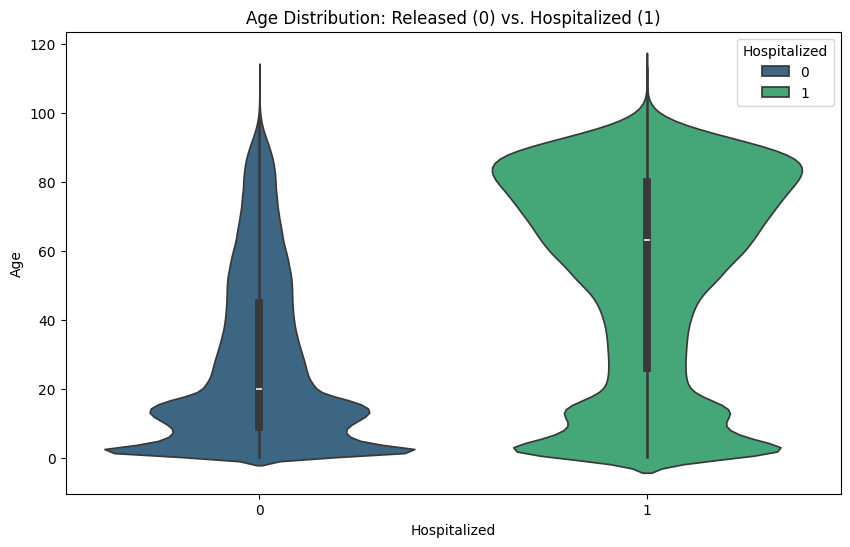

In [31]:
plt.figure(figsize=(10, 6))

# A Violin plot shows the shape of the data better than a box plot here
sns.violinplot(x='Hospitalized', y='Age', data=train_data, hue='Hospitalized', palette='viridis')

plt.title('Age Distribution: Released (0) vs. Hospitalized (1)')
plt.show()

In [32]:
predictors_num = ['Age']
print(f'Numeric Predictors: {predictors_num}')
print(f'Categorical Predictors: {predictors_cat}')

Numeric Predictors: ['Age']
Categorical Predictors: ['Diagnosis', 'Body_Part', 'Product_1', 'Injury_Mechanism', 'Location', 'Body_Part_2']


### 5. Copy Data before Encoding

In [33]:
target = ['Hospitalized']
train_data_b4_encoding = train_data[predictors_num + predictors_cat + target]
eval_data_b4_encoding = eval_data[predictors_num + predictors_cat + target]
holdout_data_b4_encoding = holdout_data[predictors_num + predictors_cat + target]



In [34]:
train_data_b4_encoding.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 8 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Age               float64
 1   Diagnosis         int64  
 2   Body_Part         int64  
 3   Product_1         str    
 4   Injury_Mechanism  str    
 5   Location          int64  
 6   Body_Part_2       float64
 7   Hospitalized      int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 548.3 MB


In [35]:
print("Train Data")
train_data_b4_encoding['Diagnosis'] = train_data_b4_encoding['Diagnosis'].astype('category')
train_data_b4_encoding['Body_Part'] = train_data_b4_encoding['Body_Part'].astype('category')
train_data_b4_encoding['Product_1'] = train_data_b4_encoding['Product_1'].astype('category')
train_data_b4_encoding['Location'] = train_data_b4_encoding['Location'].astype('category')
train_data_b4_encoding['Body_Part_2'] = train_data_b4_encoding['Body_Part_2'].astype('category')
train_data_b4_encoding['Injury_Mechanism'] = train_data_b4_encoding['Injury_Mechanism'].astype('category')
train_data_b4_encoding['Hospitalized'] = train_data_b4_encoding['Hospitalized'].astype('category')

train_data_b4_encoding.info()

print("Evalaution Data")
eval_data_b4_encoding['Diagnosis'] = eval_data_b4_encoding['Diagnosis'].astype('category')
eval_data_b4_encoding['Body_Part'] = eval_data_b4_encoding['Body_Part'].astype('category')
eval_data_b4_encoding['Product_1'] = eval_data_b4_encoding['Product_1'].astype('category')
eval_data_b4_encoding['Location'] = eval_data_b4_encoding['Location'].astype('category')
eval_data_b4_encoding['Body_Part_2'] = eval_data_b4_encoding['Body_Part_2'].astype('category')
eval_data_b4_encoding['Injury_Mechanism'] = eval_data_b4_encoding['Injury_Mechanism'].astype('category')
eval_data_b4_encoding['Hospitalized'] = eval_data_b4_encoding['Hospitalized'].astype('category')

eval_data_b4_encoding.info()

print("Holdout Data")
holdout_data_b4_encoding['Diagnosis'] = holdout_data_b4_encoding['Diagnosis'].astype('category')
holdout_data_b4_encoding['Body_Part'] = holdout_data_b4_encoding['Body_Part'].astype('category')
holdout_data_b4_encoding['Product_1'] = holdout_data_b4_encoding['Product_1'].astype('category')
holdout_data_b4_encoding['Location'] = holdout_data_b4_encoding['Location'].astype('category')
holdout_data_b4_encoding['Body_Part_2'] = holdout_data_b4_encoding['Body_Part_2'].astype('category')
holdout_data_b4_encoding['Injury_Mechanism'] = holdout_data_b4_encoding['Injury_Mechanism'].astype('category')
holdout_data_b4_encoding['Hospitalized'] = holdout_data_b4_encoding['Hospitalized'].astype('category')
holdout_data_b4_encoding.info()



Train Data
<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 8 columns):
 #   Column            Dtype   
---  ------            -----   
 0   Age               float64 
 1   Diagnosis         category
 2   Body_Part         category
 3   Product_1         category
 4   Injury_Mechanism  category
 5   Location          category
 6   Body_Part_2       category
 7   Hospitalized      category
dtypes: category(7), float64(1)
memory usage: 246.2 MB
Evalaution Data
<class 'pandas.DataFrame'>
Index: 1097244 entries, 1524627 to 3993119
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   Age               1097244 non-null  float64 
 1   Diagnosis         1097244 non-null  category
 2   Body_Part         1097244 non-null  category
 3   Product_1         1097244 non-null  category
 4   Injury_Mechanism  1097244 non-null  category
 5   Location          1097244 non-null  cat

In [36]:
train_data_b4_encoding.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 8 columns):
 #   Column            Dtype   
---  ------            -----   
 0   Age               float64 
 1   Diagnosis         category
 2   Body_Part         category
 3   Product_1         category
 4   Injury_Mechanism  category
 5   Location          category
 6   Body_Part_2       category
 7   Hospitalized      category
dtypes: category(7), float64(1)
memory usage: 246.2 MB


In [37]:
X_train = train_data_b4_encoding.drop(columns = ['Hospitalized'])
y_train = train_data_b4_encoding['Hospitalized']

X_eval = eval_data_b4_encoding.drop(columns = ['Hospitalized'])
y_eval = eval_data_b4_encoding['Hospitalized']

X_holdout = holdout_data_b4_encoding.drop(columns = ['Hospitalized'])
y_holdout = holdout_data_b4_encoding['Hospitalized']

In [46]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 99 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   cat__Diagnosis_41                        float64
 1   cat__Diagnosis_42                        float64
 2   cat__Diagnosis_46                        float64
 3   cat__Diagnosis_47                        float64
 4   cat__Diagnosis_48                        float64
 5   cat__Diagnosis_49                        float64
 6   cat__Diagnosis_50                        float64
 7   cat__Diagnosis_51                        float64
 8   cat__Diagnosis_52                        float64
 9   cat__Diagnosis_53                        float64
 10  cat__Diagnosis_54                        float64
 11  cat__Diagnosis_55                        float64
 12  cat__Diagnosis_56                        float64
 13  cat__Diagnosis_57                        float64
 14  cat__Diagnosis_58           

### 6. Perform Encoding

#### 6.1 Perfrom Scaling of Numeric Age Field 

In [38]:
print(f"Standardizing/Scaling the Age feature...")
scaler = StandardScaler()
X_train['Age_Scaled'] = scaler.fit_transform(X_train[['Age']])
X_train = X_train.drop(columns = ['Age'])

X_eval['Age_Scaled'] = scaler.fit_transform(X_eval[['Age']])
X_eval = X_eval.drop(columns = ['Age'])

X_holdout['Age_Scaled'] = scaler.fit_transform(X_holdout[['Age']])
X_holdout = X_holdout.drop(columns = ['Age'])


Standardizing/Scaling the Age feature...


#### 6.2 Perfrom Encoding for Categorical Fields 

We can use one-hot encoding to encode the below categorical varaibles:<br>
1. Diagnosis <br>
2. Body part <br>
3. Location <br>
4. Body Part_2 <br>
5. Product_1 <br>
6. Injury_Mechanism <br>

However, there are around 837 unique products in the Product_1 feature, using one-hot encoding to encode these many features could create more than 800 columns and could slow down the ML algorithms. We need a clever way to handle the Product_1 feature.

In [39]:
#### 5.1 Perform One Hot Encoding for the fields Diagnosis, Body Part, Location, Body Part_2
categorical_cols = ['Diagnosis', 'Body_Part', 'Location', 'Body_Part_2','Injury_Mechanism']
print(f"Original Training Shape: {train_data.shape}")
one_hot_encoding = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = ColumnTransformer(
        transformers=[('cat', one_hot_encoding, categorical_cols)
        ], remainder='passthrough' 
    )
preprocessor.set_output(transform="pandas")
print("Fitting and Transforming Training Data...")
X_train_encoded = preprocessor.fit_transform(X_train)

print("Transforming Eval and Test Data...")
X_eval_encoded = preprocessor.transform(X_eval)
X_holdout_encoded = preprocessor.transform(X_holdout)

print(f"Encoded Training Shape: {X_train_encoded.shape}")

Original Training Shape: (5120468, 36)
Fitting and Transforming Training Data...
Transforming Eval and Test Data...
Encoded Training Shape: (5120468, 99)


In [40]:
X_train_encoded.columns

Index(['cat__Diagnosis_41', 'cat__Diagnosis_42', 'cat__Diagnosis_46',
       'cat__Diagnosis_47', 'cat__Diagnosis_48', 'cat__Diagnosis_49',
       'cat__Diagnosis_50', 'cat__Diagnosis_51', 'cat__Diagnosis_52',
       'cat__Diagnosis_53', 'cat__Diagnosis_54', 'cat__Diagnosis_55',
       'cat__Diagnosis_56', 'cat__Diagnosis_57', 'cat__Diagnosis_58',
       'cat__Diagnosis_59', 'cat__Diagnosis_60', 'cat__Diagnosis_61',
       'cat__Diagnosis_62', 'cat__Diagnosis_63', 'cat__Diagnosis_64',
       'cat__Diagnosis_65', 'cat__Diagnosis_66', 'cat__Diagnosis_67',
       'cat__Diagnosis_68', 'cat__Diagnosis_69', 'cat__Diagnosis_71',
       'cat__Diagnosis_72', 'cat__Diagnosis_73', 'cat__Diagnosis_74',
       'cat__Body_Part_0', 'cat__Body_Part_30', 'cat__Body_Part_31',
       'cat__Body_Part_32', 'cat__Body_Part_33', 'cat__Body_Part_34',
       'cat__Body_Part_35', 'cat__Body_Part_36', 'cat__Body_Part_37',
       'cat__Body_Part_38', 'cat__Body_Part_75', 'cat__Body_Part_76',
       'cat__Body_Par

### 6.3 Perfrom Target Encoding for the Product_1 Field 

In [41]:
print(f"Target Encoding Product_1 - Started")
encoder = ce.TargetEncoder(cols=['remainder__Product_1'], smoothing=10)
print("Target Encoding on Train Set Started")
X_train = encoder.fit_transform(X_train_encoded, y_train)
print("Target Encoding on Train Set Completed")
print("Transforming the evaluation dataset")
X_eval = encoder.transform(X_eval_encoded)
print("Transforming the holdout dataset")
X_holdout = encoder.transform(X_holdout_encoded)
print(f"Target Encoding Product_1 - Completed")

Target Encoding Product_1 - Started
Target Encoding on Train Set Started
Target Encoding on Train Set Completed
Transforming the evaluation dataset
Transforming the holdout dataset
Target Encoding Product_1 - Completed


In [42]:
X_train.head()

,cat__Diagnosis_41,cat__Diagnosis_42,cat__Diagnosis_46,cat__Diagnosis_47,cat__Diagnosis_48,cat__Diagnosis_49,cat__Diagnosis_50,cat__Diagnosis_51,cat__Diagnosis_52,cat__Diagnosis_53,cat__Diagnosis_54,cat__Diagnosis_55,cat__Diagnosis_56,cat__Diagnosis_57,cat__Diagnosis_58,cat__Diagnosis_59,cat__Diagnosis_60,cat__Diagnosis_61,cat__Diagnosis_62,cat__Diagnosis_63,cat__Diagnosis_64,cat__Diagnosis_65,cat__Diagnosis_66,cat__Diagnosis_67,cat__Diagnosis_68,cat__Diagnosis_69,cat__Diagnosis_71,cat__Diagnosis_72,cat__Diagnosis_73,cat__Diagnosis_74,cat__Body_Part_0,cat__Body_Part_30,cat__Body_Part_31,cat__Body_Part_32,cat__Body_Part_33,cat__Body_Part_34,cat__Body_Part_35,cat__Body_Part_36,cat__Body_Part_37,cat__Body_Part_38,cat__Body_Part_75,cat__Body_Part_76,cat__Body_Part_77,cat__Body_Part_79,cat__Body_Part_80,cat__Body_Part_81,cat__Body_Part_82,cat__Body_Part_83,cat__Body_Part_84,cat__Body_Part_85,cat__Body_Part_87,cat__Body_Part_88,cat__Body_Part_89,cat__Body_Part_92,cat__Body_Part_93,cat__Body_Part_94,cat__Location_0,cat__Location_1,cat__Location_2,cat__Location_4,cat__Location_5,cat__Location_6,cat__Location_7,cat__Location_8,cat__Location_9,cat__Body_Part_2_0.0,cat__Body_Part_2_30.0,cat__Body_Part_2_31.0,cat__Body_Part_2_32.0,cat__Body_Part_2_33.0,cat__Body_Part_2_34.0,cat__Body_Part_2_35.0,cat__Body_Part_2_36.0,cat__Body_Part_2_37.0,cat__Body_Part_2_38.0,cat__Body_Part_2_75.0,cat__Body_Part_2_76.0,cat__Body_Part_2_77.0,cat__Body_Part_2_79.0,cat__Body_Part_2_80.0,cat__Body_Part_2_81.0,cat__Body_Part_2_82.0,cat__Body_Part_2_83.0,cat__Body_Part_2_84.0,cat__Body_Part_2_85.0,cat__Body_Part_2_87.0,cat__Body_Part_2_88.0,cat__Body_Part_2_89.0,cat__Body_Part_2_92.0,cat__Body_Part_2_93.0,cat__Body_Part_2_94.0,cat__Injury_Mechanism_Burn,cat__Injury_Mechanism_Fall,cat__Injury_Mechanism_Ingestion/Choking,cat__Injury_Mechanism_Laceration/Cut,cat__Injury_Mechanism_Other/Unspecified,cat__Injury_Mechanism_Struck By,remainder__Product_1,remainder__Age_Scaled
6181068,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.29,0.65
3981895,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.05,-0.92
850890,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.17,1.84
5177385,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.03,-0.69
5858098,0.00,0.00,

### 7. Save the data to the interim folder for future use

Concatenate Predictor and Target variables and save it for the next step of the pipeline

In [43]:
train_df = pd.concat([X_train, y_train], axis=1)
eval_df = pd.concat([X_eval, y_eval], axis=1)
holdout_df = pd.concat([X_holdout, y_holdout], axis=1)

In [44]:
#data.to_csv('../data/processed/neiss_processed_data.csv', index=False)
train_df.to_parquet('../data/processed/neiss_feature-engineered_train_data.parquet')
eval_df.to_parquet('../data/processed/neiss_feature-engineered_eval_data.parquet')
holdout_df.to_parquet('../data/processed/neiss_feature-engineered_holdout_data.parquet')

In [45]:
n = gc.collect()
print(f"Number of unreachable objects collected: {n}")

Number of unreachable objects collected: 82458
